# **AUtoEncoder**

In [ ]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

normal_class = 0  # T-shirt / Top

train_selected = [x for x in train_dataset if x[1] == normal_class]
test_selected  = [x for x in test_dataset]

train_loader = DataLoader(train_selected, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_selected, batch_size=64, shuffle=False)

print("Train normal samples:", len(train_selected))
print("Test samples:", len(test_selected))

Using device: cpu
Train normal samples: 6000
Test samples: 10000


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,16,3,stride=2,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,64,7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,7),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.decoder(self.encoder(x))

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs,_ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")


model.eval()
train_losses = []
with torch.no_grad():
    for imgs,_ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = ((outputs - imgs)**2).mean(dim=(1,2,3))
        train_losses.extend(loss.cpu().numpy())

train_losses = np.array(train_losses)
threshold = train_losses.mean() + 3 * train_losses.std()
print("Calculated Threshold:", threshold)


Epoch [1/10] Loss: 0.0497
Epoch [2/10] Loss: 0.0232
Epoch [3/10] Loss: 0.0173
Epoch [4/10] Loss: 0.0145
Epoch [5/10] Loss: 0.0126
Epoch [6/10] Loss: 0.0113
Epoch [7/10] Loss: 0.0103
Epoch [8/10] Loss: 0.0097
Epoch [9/10] Loss: 0.0093
Epoch [10/10] Loss: 0.0089
Calculated Threshold: 0.028854538


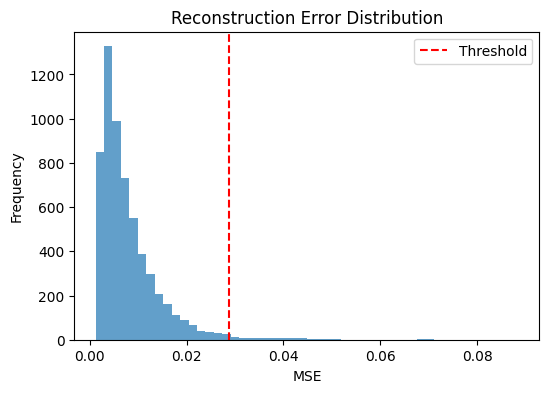

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(train_losses, bins=50, alpha=0.7)
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.legend()
plt.show()


              precision    recall  f1-score   support

       False       0.14      0.98      0.24      1000
        True       0.99      0.33      0.49      9000

    accuracy                           0.39     10000
   macro avg       0.57      0.65      0.37     10000
weighted avg       0.91      0.39      0.47     10000

ROC AUC: 0.8984454444444445


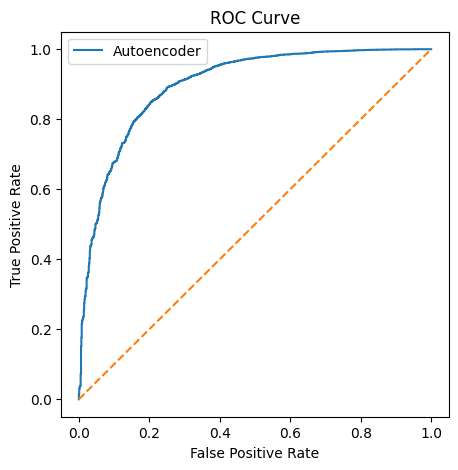

In [ ]:
y_true, y_scores = [], []

with torch.no_grad():
    for imgs,labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = ((outputs - imgs)**2).mean(dim=(1,2,3))
        y_scores.extend(loss.cpu().numpy())
        y_true.extend((labels != normal_class).cpu().numpy())

y_true   = np.array(y_true)
y_scores = np.array(y_scores)
y_pred   = y_scores > threshold

print(classification_report(y_true, y_pred))
print("ROC AUC:", roc_auc_score(y_true, y_scores))


fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label="Autoencoder")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

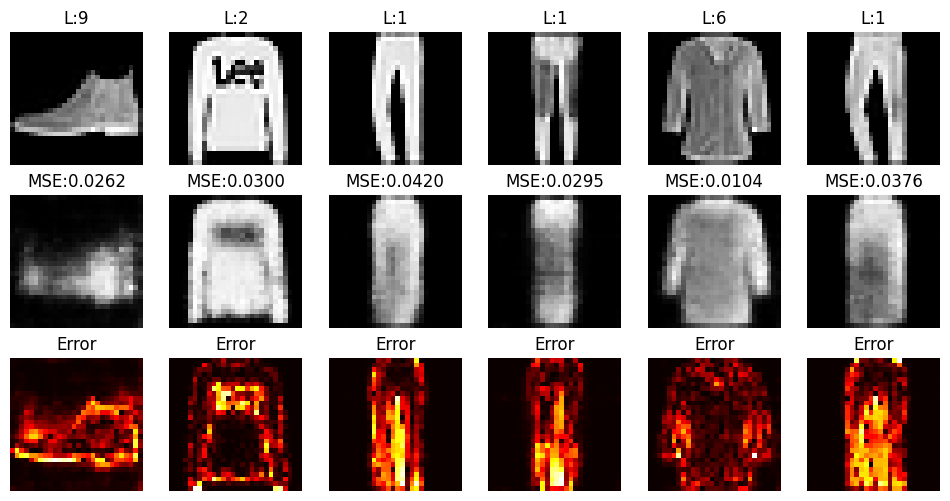

In [ ]:
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)
    losses = ((outputs - imgs)**2).mean(dim=(1,2,3))

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(3,6,i+1)
    plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
    plt.title(f"L:{labels[i].item()}")
    plt.axis('off')

    plt.subplot(3,6,i+7)
    plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
    plt.title(f"MSE:{losses[i]:.4f}")
    plt.axis('off')

    heatmap = (imgs[i] - outputs[i]).abs().cpu().squeeze()
    plt.subplot(3,6,i+13)
    plt.imshow(heatmap, cmap='hot')
    plt.title("Error")
    plt.axis('off')

plt.show()

In [ ]:
def load_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((28,28))
    img_tensor = transform(img).unsqueeze(0)
    return img, img_tensor

def test_image(img_tensor, threshold):
    with torch.no_grad():
        recon = model(img_tensor.to(device))
    diff = (img_tensor.to(device) - recon).pow(2)
    score = diff.mean().item()
    return recon.cpu(), diff.cpu(), score, score > threshold

Anomaly Score: 0.08234347403049469
Is Anomaly: True


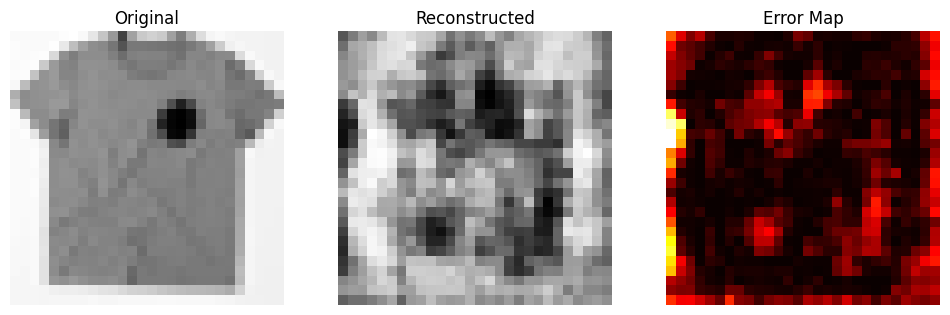

In [ ]:
image_path = "/content/photo_2025-12-11_22-44-05.jpg"
orig_img, img_tensor = load_image(image_path)
recon_img, diff, score, is_anomaly = test_image(img_tensor, threshold)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(orig_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Reconstructed")
plt.imshow(recon_img.squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Error Map")
plt.imshow(diff.squeeze(), cmap='hot')
plt.axis('off')

print("Anomaly Score:", score)
print("Is Anomaly:", is_anomaly)
